In [1]:
# Dynamic pricing simulation

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8")
sns.set_palette("deep")

In [2]:
# Load processed data
daily = pd.read_csv("../data/processed/daily_aggregated.csv")

daily = daily[(daily["daily_demand"] > 0) & (daily["avg_price"] > 0)]

# Use corrected elasticity
elasticity = -0.02

# Baseline demand
base_demand = daily["daily_demand"].mean()
reference_price = daily["avg_price"].mean()

# Business assumptions
capacity = 120
simulation_days = 30
price_floor = 50
price_ceiling = 500

print("Elasticity:", elasticity)

Elasticity: -0.02


In [3]:
def demand_function(price):
    return base_demand * (price / reference_price) ** elasticity

In [4]:
static_price = reference_price

rooms_left_static = capacity
revenue_static = 0

revenue_over_time_static = []
rooms_over_time_static = []

for day in range(simulation_days):

    demand = min(demand_function(static_price), rooms_left_static)
    
    revenue_static += static_price * demand
    rooms_left_static -= demand
    
    revenue_over_time_static.append(revenue_static)
    rooms_over_time_static.append(rooms_left_static)
    
    if rooms_left_static <= 0:
        break

print("Total Revenue (Static Pricing):", round(revenue_static, 2))

Total Revenue (Static Pricing): 11839.6


In [5]:
# Use optimal price from File 4
optimal_price = 190.96

rooms_left_opt = capacity
revenue_opt = 0

revenue_over_time_opt = []
rooms_over_time_opt = []

for day in range(simulation_days):

    demand = min(demand_function(optimal_price), rooms_left_opt)
    
    revenue_opt += optimal_price * demand
    rooms_left_opt -= demand
    
    revenue_over_time_opt.append(revenue_opt)
    rooms_over_time_opt.append(rooms_left_opt)
    
    if rooms_left_opt <= 0:
        break

print("Total Revenue (Optimized Pricing):", round(revenue_opt, 2))

Total Revenue (Optimized Pricing): 22915.2


In [6]:
lift = (revenue_opt - revenue_static) / revenue_static * 100

print("Revenue Lift (%):", round(lift, 2))

Revenue Lift (%): 93.55


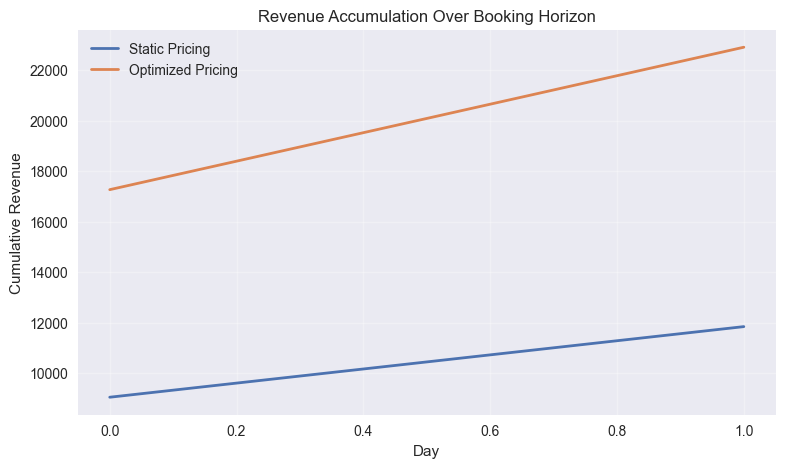

In [7]:
plt.figure(figsize=(9,5))
plt.plot(revenue_over_time_static, linewidth=2, label="Static Pricing")
plt.plot(revenue_over_time_opt, linewidth=2, label="Optimized Pricing")

plt.title("Revenue Accumulation Over Booking Horizon")
plt.xlabel("Day")
plt.ylabel("Cumulative Revenue")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

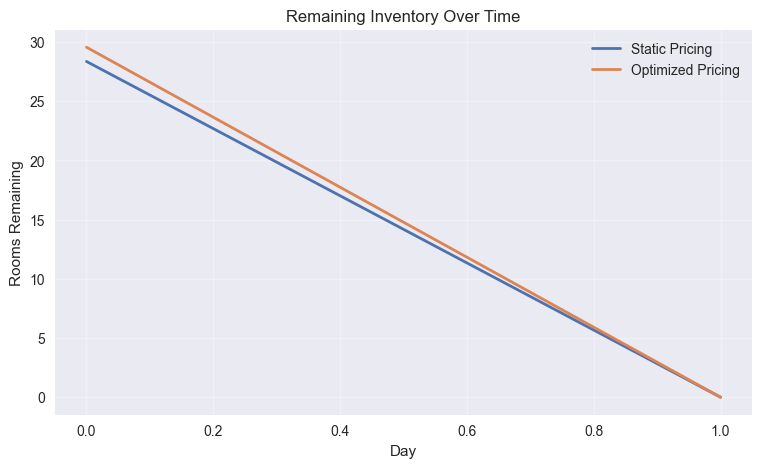

In [8]:
plt.figure(figsize=(9,5))
plt.plot(rooms_over_time_static, linewidth=2, label="Static Pricing")
plt.plot(rooms_over_time_opt, linewidth=2, label="Optimized Pricing")

plt.title("Remaining Inventory Over Time")
plt.xlabel("Day")
plt.ylabel("Rooms Remaining")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

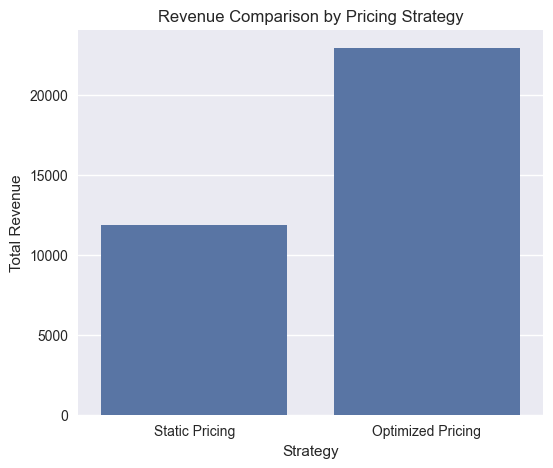

In [9]:
results = pd.DataFrame({
    "Strategy": ["Static Pricing", "Optimized Pricing"],
    "Total Revenue": [revenue_static, revenue_opt]
})

plt.figure(figsize=(6,5))
sns.barplot(x="Strategy", y="Total Revenue", data=results)
plt.title("Revenue Comparison by Pricing Strategy")
plt.ylabel("Total Revenue")
plt.show()

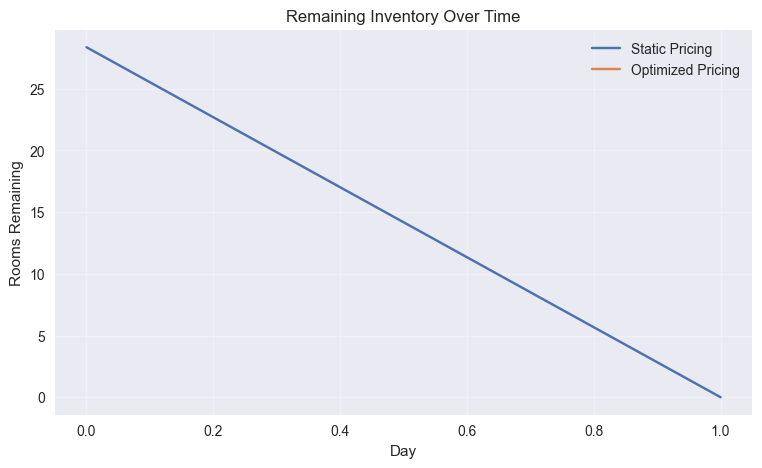

In [10]:
plt.figure(figsize=(9,5))
plt.plot(rooms_over_time_static, label="Static Pricing")
plt.plot(rooms_over_time_opt, label="Optimized Pricing")

plt.title("Remaining Inventory Over Time")
plt.xlabel("Day")
plt.ylabel("Rooms Remaining")
plt.legend()
plt.grid(alpha=0.3)
plt.show()